# Definição - Palavras Chave

Dado um texto, iremos utilizar essas funções para saber a intensidade e a positividade/negatividade do texto.

In [11]:
palavras_chave_positivas = [
    'bom',
    'positivo',
    'interessante',
    'maravilhoso',
    'ótimo',
    'surpreendente',
    'fantástico',
    'perfeito'
    ]

palavras_chave_negativas = [
    'ruim',
    'péssimo',
    'horrível',
    'terrível',
    'lamentável',
    'decepcionante',
    'frustrante'
    ]

palavras_chave_intensificadoras = [
    'muito',
    'bastante',
    'extremamente',
    'incrivelmente',
    'completamente',
    'absolutamente'
    ]
palavras_chave_negacoes = [
    'não',
    'jamais',
    'nenhum',
    'nada',
    'em nenhum momento',
    'absolutamente não'
    ]


def calcular_fp(txt: str) -> float:
  palavras = txt.split(' ')
  freq_palavras_pos = len([p for p in palavras if p.lower() in palavras_chave_positivas])
  freq_palavras_neg = len([p for p in palavras if p.lower() in palavras_chave_negativas])
  freq_palavras_negacao = len([p for p in palavras if p.lower() in palavras_chave_negacoes])
  total_palavras = len(palavras)

  return (freq_palavras_pos - freq_palavras_negacao) / total_palavras

def calcular_fn(txt: str) -> float:
  palavras = txt.split(' ')
  freq_palavras_pos = len([p for p in palavras if p.lower() in palavras_chave_positivas])
  freq_palavras_neg = len([p for p in palavras if p.lower() in palavras_chave_negativas])
  freq_palavras_negacao = len([p for p in palavras if p.lower() in palavras_chave_negacoes])
  total_palavras = len(palavras)

  return (freq_palavras_neg - freq_palavras_negacao) / total_palavras

def calcular_intensidade(txt: str) -> float:
  palavras = txt.split(' ')
  freq_palavras_inten = len([p for p in palavras if p.lower() in palavras_chave_intensificadoras])
  total_palavras = len(palavras)

  return freq_palavras_inten / total_palavras
def calcular_negacao(txt: str) -> float:
  palavras = txt.lower().split(' ')
  freq_negacao = len([p for p in palavras if p in palavras_chave_negacoes])
  return freq_negacao / len(palavras)

# Definição - Fuzzy

In [12]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

positividade = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Positividade')
negatividade = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Negatividade')
intensidade = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Intensidade')
negacao = ctrl.Antecedent(np.arange(0, 1.1, 0.1), 'Negacao')
polaridade = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'Polaridade')

positividade['Baixa'] = fuzz.trimf(positividade.universe, [0, 0, 0.3])
positividade['Média'] = fuzz.trimf(positividade.universe, [0.2, 0.4, 0.6])
positividade['Alta'] = fuzz.trimf(positividade.universe, [0.4, 1, 1])

negatividade['Baixa'] = fuzz.trimf(negatividade.universe, [0, 0, 0.3])
negatividade['Média'] = fuzz.trimf(negatividade.universe, [0.2, 0.4, 0.6])
negatividade['Alta'] = fuzz.trimf(negatividade.universe, [0.4, 1, 1])

intensidade['Baixa'] = fuzz.trimf(intensidade.universe, [0, 0, 0.3])
intensidade['Média'] = fuzz.trimf(intensidade.universe, [0.2, 0.4, 0.6])
intensidade['Alta'] = fuzz.trimf(intensidade.universe, [0.4, 1, 1])

polaridade['Negativa'] = fuzz.trimf(polaridade.universe, [0, 0, 0.3])
polaridade['Neutra'] = fuzz.trimf(polaridade.universe, [0.2, 0.4, 0.6])
polaridade['Positiva'] = fuzz.trimf(polaridade.universe, [0.4, 1, 1])

negacao['Baixa'] = fuzz.trimf(negacao.universe, [0, 0, 0.3])
negacao['Média'] = fuzz.trimf(negacao.universe, [0.2, 0.4, 0.6])
negacao['Alta'] = fuzz.trimf(negacao.universe, [0.4, 1, 1])

## Gráficos

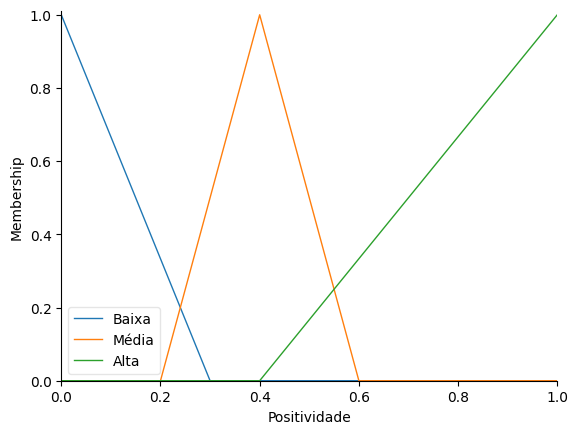

In [13]:
positividade.view()

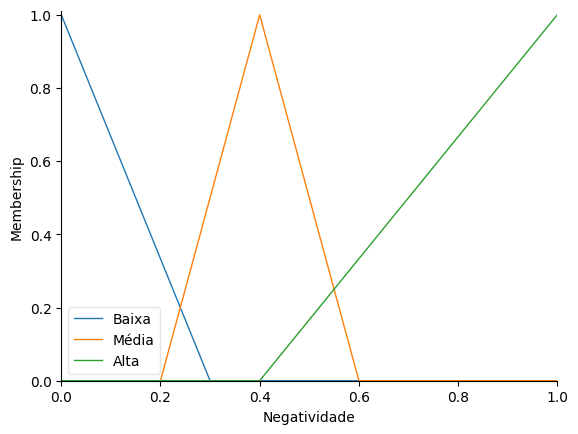

In [14]:
negatividade.view()

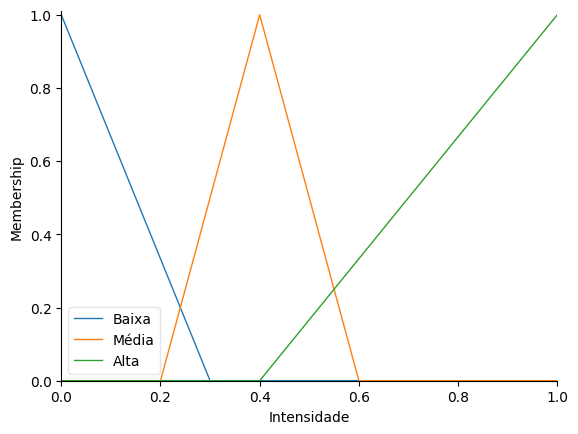

In [15]:
intensidade.view()

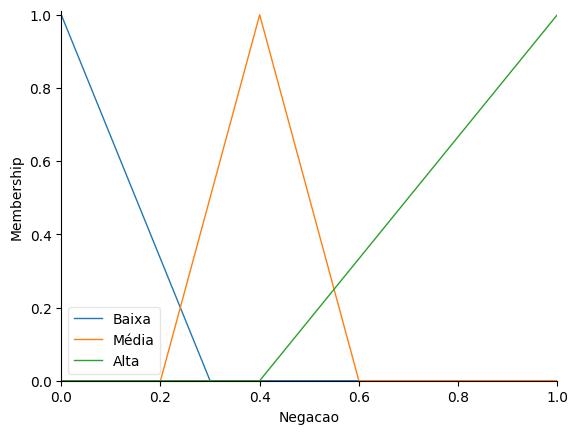

In [17]:
negacao.view()

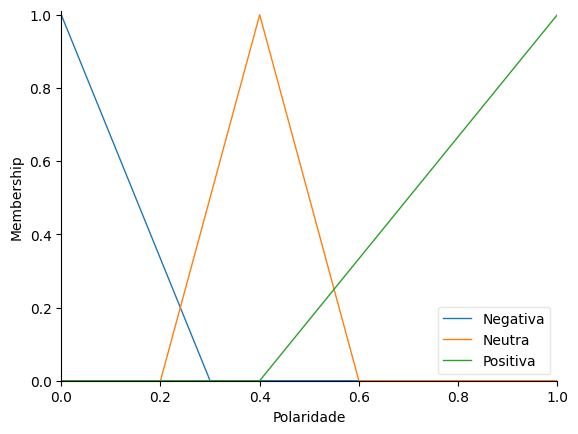

In [16]:
polaridade.view()

# Regras

In [18]:
rule1 = ctrl.Rule(positividade['Alta'] & negacao['Baixa'], polaridade['Positiva'])
rule2 = ctrl.Rule(negatividade['Alta'] & negacao['Baixa'], polaridade['Negativa'])
rule3 = ctrl.Rule(positividade['Alta'] & intensidade['Alta'], polaridade['Positiva'])
rule4 = ctrl.Rule(negatividade['Alta'] & negacao['Alta'], polaridade['Neutra'])
rule5 = ctrl.Rule(positividade['Média'] & negacao['Média'], polaridade['Neutra'])
rule6 = ctrl.Rule(positividade['Alta'] | negatividade['Baixa'], polaridade['Positiva'])
rule7 = ctrl.Rule(positividade['Baixa'] | negatividade['Alta'], polaridade['Negativa'])

# Simulação

In [19]:
sentimento_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
sentimento_simulador = ctrl.ControlSystemSimulation(sentimento_ctrl)
texto = 'the last of us é uma serie muito boa'
print(f'Positivo: {calcular_fp(texto):.2f}')
print(f'Negativo: {calcular_fn(texto):.2f}')
print(f'Intensidade: {calcular_intensidade(texto):.2f}')
print(f'Negação: {calcular_negacao(texto):.2f}')
sentimento_simulador.input['Positividade'] = calcular_fp(texto)
sentimento_simulador.input['Negatividade'] = calcular_fn(texto)
sentimento_simulador.input['Intensidade'] = calcular_intensidade(texto)
sentimento_simulador.input['Negacao'] = calcular_negacao(texto)
sentimento_simulador.compute()

print(f'Polaridade: {sentimento_simulador.output["Polaridade"]:.2f}')
if sentimento_simulador.output["Polaridade"] <= 0.3:
    print("🔴 Sentimento: Negativo")
elif sentimento_simulador.output["Polaridade"] <= 0.6:
    print("🟡 Sentimento: Neutro")
else:
    print("🟢 Sentimento: Positivo")

Positivo: 0.00
Negativo: 0.00
Intensidade: 0.11
Negação: 0.00
Polaridade: 0.57
🟡 Sentimento: Neutro


## Gráficos

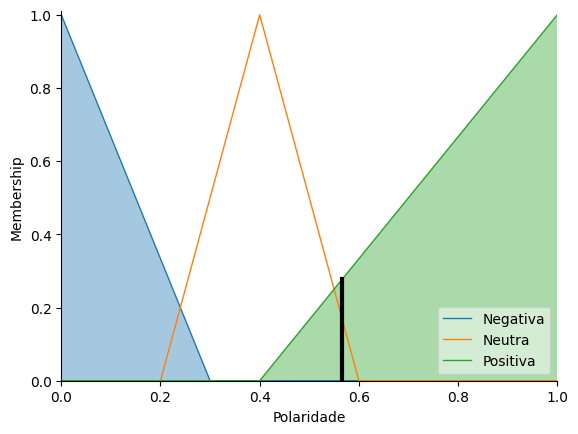

In [20]:
polaridade.view(sim=sentimento_simulador)